In [1]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
import json

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from xgboost import XGBClassifier

In [2]:
df = pd.read_csv('../datasets/cleaned_fertilizer.csv')
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
df.head()

Shape: (99, 12)
Columns: ['Temparature', 'Humidity', 'Moisture', 'Soil Type', 'Crop Type', 'Nitrogen', 'Potassium', 'Phosphorous', 'Fertilizer Name', 'soil_encoded', 'crop_encoded', 'fertilizer_encoded']


,Temparature,Humidity,Moisture,Soil Type,Crop Type,Nitrogen,Potassium,Phosphorous,Fertilizer Name,soil_encoded,crop_encoded,fertilizer_encoded
0,26,52,38,Sandy,Maize,37,0,0,Urea,4,3,6
1,29,52,45,Loamy,Sugarcane,12,0,36,Dap,2,8,5
2,34,65,62,Black,Cotton,7,9,30,14-35-14,0,1,1
3,32,62,34,Red,Tobacco,22,0,20,28-28,3,9,4
4,28,54,46,Clayey,Paddy,35,0,0,Urea,1,6,6


In [3]:
print("Unique Fertilizers:", df['Fertilizer Name'].unique())
print("\nUnique Soil Types:", df['Soil Type'].unique())
print("\nUnique Crop Types:", df['Crop Type'].unique())
print("\nFertilizer class count:", df['fertilizer_encoded'].nunique())

Unique Fertilizers: <ArrowStringArray>
['Urea', 'Dap', '14-35-14', '28-28', '17-17-17', '20-20', '10-26-26']
Length: 7, dtype: str

Unique Soil Types: <ArrowStringArray>
['Sandy', 'Loamy', 'Black', 'Red', 'Clayey']
Length: 5, dtype: str

Unique Crop Types: <ArrowStringArray>
[      'Maize',   'Sugarcane',      'Cotton',     'Tobacco',       'Paddy',
      'Barley',       'Wheat',     'Millets',   'Oil Seeds',      'Pulses',
 'Ground Nuts']
Length: 11, dtype: str

Fertilizer class count: 7


In [4]:
# Input features
X = df[['Temparature', 'Humidity', 'Moisture',
        'soil_encoded', 'crop_encoded',
        'Nitrogen', 'Potassium', 'Phosphorous']]

# Target
y = df['fertilizer_encoded']

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("Total fertilizer classes:", y.nunique())

Features shape: (99, 8)
Target shape: (99,)
Total fertilizer classes: 7


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 79
Testing samples: 20


In [7]:
models = {
    'Random Forest': RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ),
    'XGBoost': XGBClassifier(
        n_estimators=100,
        random_state=42,
        eval_metric='mlogloss',
        verbosity=0
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=100,
        random_state=42
    ),
    'Logistic Regression': LogisticRegression(
        max_iter=2000,
        random_state=42
    )
}

results = {}

print("Training models...\n")
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f"✅ {name}: {acc*100:.2f}%")

Training models...

✅ Random Forest: 100.00%
✅ XGBoost: 100.00%
✅ Gradient Boosting: 95.00%
✅ Logistic Regression: 100.00%


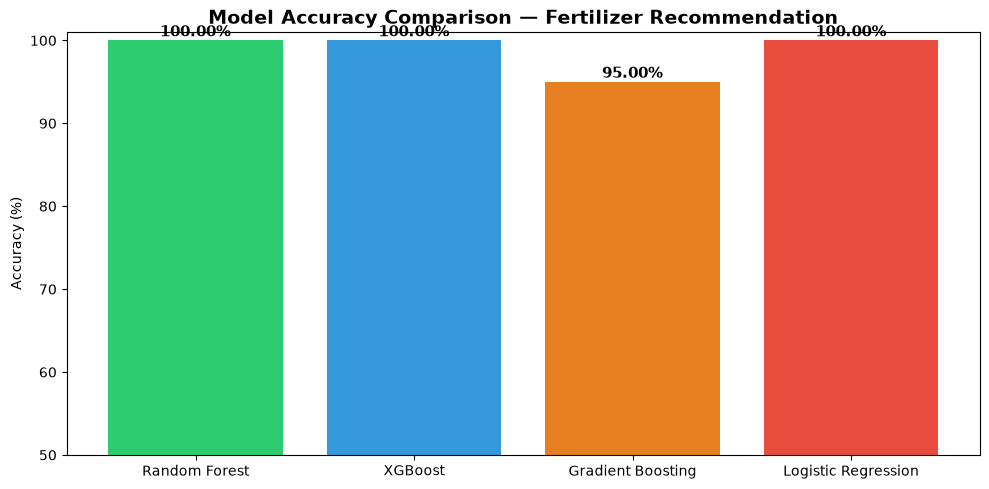

Chart saved!


In [8]:
plt.figure(figsize=(10, 5))
colors = ['#2ecc71', '#3498db', '#e67e22', '#e74c3c']
bars = plt.bar(results.keys(),
               [v*100 for v in results.values()],
               color=colors)
plt.title('Model Accuracy Comparison — Fertilizer Recommendation',
          fontsize=14, fontweight='bold')
plt.ylabel('Accuracy (%)')
plt.ylim(50, 101)
for bar, (k, v) in zip(bars, results.items()):
    plt.text(bar.get_x() + bar.get_width()/2,
             v*100 + 0.5,
             f"{v*100:.2f}%",
             ha='center',
             fontweight='bold',
             fontsize=11)
plt.tight_layout()
plt.savefig('../models/fertilizer_model_comparison.png', dpi=150)
plt.show()
print("Chart saved!")

In [9]:
best_name = max(results, key=results.get)
best_model = models[best_name]

print(f"🏆 Best Model: {best_name}")
print(f"🎯 Accuracy: {results[best_name]*100:.2f}%\n")

y_pred_best = best_model.predict(X_test)
le_fertilizer = pickle.load(open('../models/fertilizer_encoder.pkl', 'rb'))

print("Classification Report:")
print(classification_report(
    y_test,
    y_pred_best,
    target_names=le_fertilizer.classes_
))

🏆 Best Model: Random Forest
🎯 Accuracy: 100.00%

Classification Report:
              precision    recall  f1-score   support

    10-26-26       1.00      1.00      1.00         1
    14-35-14       1.00      1.00      1.00         3
    17-17-17       1.00      1.00      1.00         1
       20-20       1.00      1.00      1.00         3
       28-28       1.00      1.00      1.00         3
         Dap       1.00      1.00      1.00         4
        Urea       1.00      1.00      1.00         5

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20



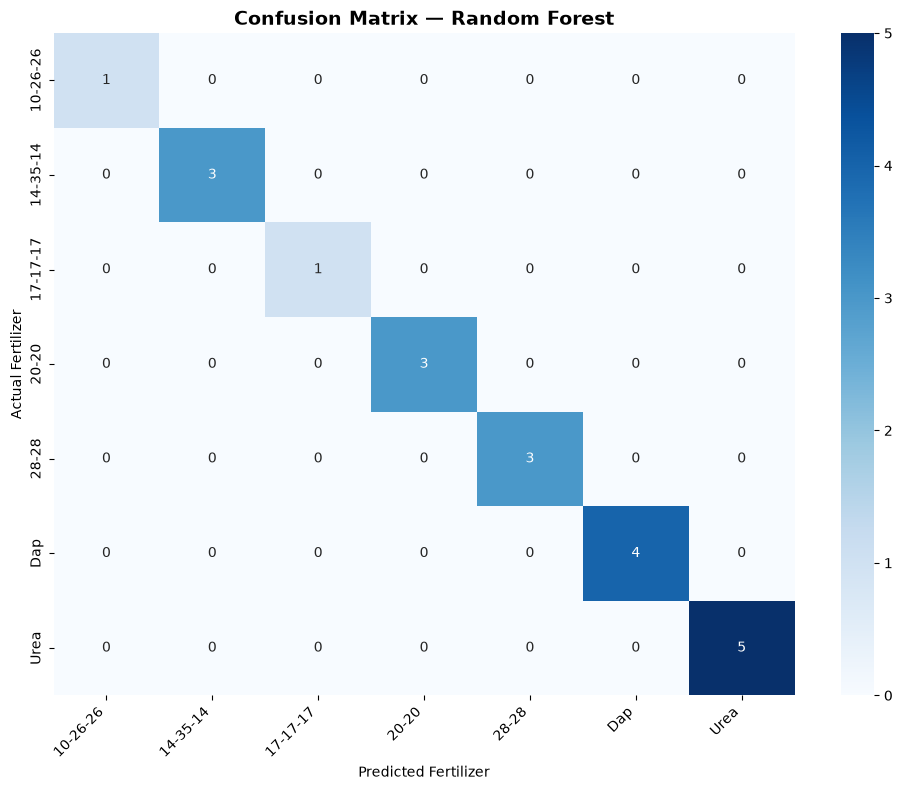

Confusion matrix saved!


In [10]:
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(10, 8))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=le_fertilizer.classes_,
            yticklabels=le_fertilizer.classes_)
plt.title(f'Confusion Matrix — {best_name}',
          fontsize=14, fontweight='bold')
plt.ylabel('Actual Fertilizer')
plt.xlabel('Predicted Fertilizer')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../models/fertilizer_confusion_matrix.png', dpi=150)
plt.show()
print("Confusion matrix saved!")

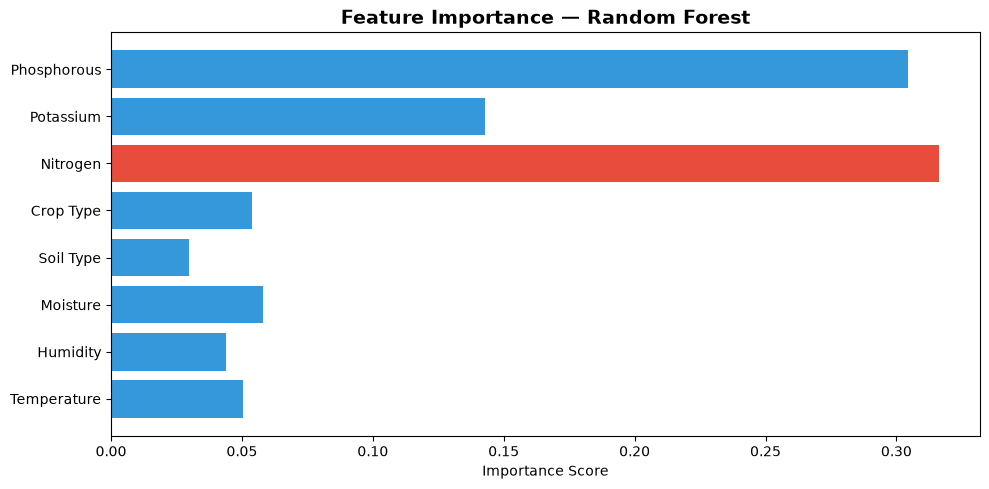

Feature importance chart saved!


In [11]:
if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
    feature_names = ['Temperature', 'Humidity', 'Moisture',
                     'Soil Type', 'Crop Type',
                     'Nitrogen', 'Potassium', 'Phosphorous']

    plt.figure(figsize=(10, 5))
    colors = ['#e74c3c' if x == max(importances) else '#3498db'
              for x in importances]
    plt.barh(feature_names, importances, color=colors)
    plt.title(f'Feature Importance — {best_name}',
              fontsize=14, fontweight='bold')
    plt.xlabel('Importance Score')
    plt.tight_layout()
    plt.savefig('../models/fertilizer_feature_importance.png', dpi=150)
    plt.show()
    print("Feature importance chart saved!")

In [14]:
le_soil = pickle.load(open('../models/soil_encoder.pkl', 'rb'))
le_crop_fert = pickle.load(open('../models/crop_fert_encoder.pkl', 'rb'))

# Using actual crop and soil names from dataset
sample_soil = 'Loamy'
sample_crop = 'Paddy'

# Encode them
soil_enc = le_soil.transform([sample_soil])[0]
crop_enc = le_crop_fert.transform([sample_crop])[0]

sample = pd.DataFrame([[26, 52, 38, soil_enc, crop_enc, 12, 0, 25]],
                      columns=['Temparature', 'Humidity', 'Moisture',
                               'soil_encoded', 'crop_encoded',
                               'Nitrogen', 'Potassium', 'Phosphorous'])

pred_enc = best_model.predict(sample)[0]
pred_fertilizer = le_fertilizer.inverse_transform([pred_enc])[0]

print("🌿 Fertilizer Recommendation Test")
print("-" * 35)
print(f"  Soil Type : {sample_soil}")
print(f"  Crop      : {sample_crop}")
print(f"  Nitrogen  : 12 | Potassium: 0 | Phosphorous: 25")
print(f"\n  ✅ Recommended Fertilizer: {pred_fertilizer}")

🌿 Fertilizer Recommendation Test
-----------------------------------
  Soil Type : Loamy
  Crop      : Paddy
  Nitrogen  : 12 | Potassium: 0 | Phosphorous: 25

  ✅ Recommended Fertilizer: 20-20


In [15]:
pickle.dump(best_model, open('../models/fertilizer_model.pkl', 'wb'))
print(f"✅ Best model saved: fertilizer_model.pkl")
print(f"   Algorithm: {best_name}")
print(f"   Accuracy: {results[best_name]*100:.2f}%")

✅ Best model saved: fertilizer_model.pkl
   Algorithm: Random Forest
   Accuracy: 100.00%


In [16]:
metadata = {
    'best_model': best_name,
    'accuracy': round(results[best_name] * 100, 2),
    'all_results': {k: round(v*100, 2) for k, v in results.items()},
    'features': ['Temparature', 'Humidity', 'Moisture',
                 'soil_encoded', 'crop_encoded',
                 'Nitrogen', 'Potassium', 'Phosphorous'],
    'total_classes': int(y.nunique())
}

with open('../models/fertilizer_model_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=4)

print("✅ Metadata saved!")
print(json.dumps(metadata, indent=4))

✅ Metadata saved!
{
    "best_model": "Random Forest",
    "accuracy": 100.0,
    "all_results": {
        "Random Forest": 100.0,
        "XGBoost": 100.0,
        "Gradient Boosting": 95.0,
        "Logistic Regression": 100.0
    },
    "features": [
        "Temparature",
        "Humidity",
        "Moisture",
        "soil_encoded",
        "crop_encoded",
        "Nitrogen",
        "Potassium",
        "Phosphorous"
    ],
    "total_classes": 7
}


In [17]:
print("=" * 40)
print("  PHASE 3 — FERTILIZER MODEL COMPLETE")
print("=" * 40)

loaded = pickle.load(open('../models/fertilizer_model.pkl', 'rb'))
pred = loaded.predict(sample)[0]
result = le_fertilizer.inverse_transform([pred])[0]

print(f"\n✅ Model loads correctly")
print(f"✅ Algorithm: {best_name}")
print(f"✅ Accuracy: {results[best_name]*100:.2f}%")
print(f"✅ Test prediction: {result}")
print("\nFiles saved in models/:")
print("  - fertilizer_model.pkl")
print("  - fertilizer_model_metadata.json")
print("  - fertilizer_model_comparison.png")
print("  - fertilizer_confusion_matrix.png")
print("  - fertilizer_feature_importance.png")

  PHASE 3 — FERTILIZER MODEL COMPLETE

✅ Model loads correctly
✅ Algorithm: Random Forest
✅ Accuracy: 100.00%
✅ Test prediction: 20-20

Files saved in models/:
  - fertilizer_model.pkl
  - fertilizer_model_metadata.json
  - fertilizer_model_comparison.png
  - fertilizer_confusion_matrix.png
  - fertilizer_feature_importance.png
